# Import Libraries

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Data Handeling

In [14]:
df = pd.read_csv('/content/car_purchasing.csv.xls', encoding='ISO-8859-1')

In [15]:
df.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [16]:
df = df.drop(columns=['customer name', 'customer e-mail', 'country', 'gender', 'age'])

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   annual Salary        500 non-null    float64
 1   credit card debt     500 non-null    float64
 2   net worth            500 non-null    float64
 3   car purchase amount  500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


In [18]:
X = df.drop(columns=['car purchase amount'])
y = df['car purchase amount']

In [19]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

In [21]:
X_train.shape

(400, 3)

# TF Model Arch

In [22]:
model = Sequential([
    Dense(14, activation='relu', input_dim=3),
    Dense(4, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(optimizer='adam', loss='MSE', metrics=['MAE'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(X_train, y_train, epochs=200, validation_split=0.2)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - MAE: 44163.0078 - loss: 2065748224.0000 - val_MAE: 44311.2305 - val_loss: 2068784768.0000
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - MAE: 44162.9258 - loss: 2065741184.0000 - val_MAE: 44311.1484 - val_loss: 2068777344.0000
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - MAE: 44162.8477 - loss: 2065733632.0000 - val_MAE: 44311.0547 - val_loss: 2068769152.0000
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - MAE: 44162.7422 - loss: 2065724672.0000 - val_MAE: 44310.9492 - val_loss: 2068759296.0000
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - MAE: 44162.6328 - loss: 2065714560.0000 - val_MAE: 44310.8242 - val_loss: 2068748032.0000
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - MAE: 44162.5000 - loss: 2065702656.0000 - val_MAE: 44310.6797 - val_loss: 2068734976.0000
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - MAE: 44162.3438 - loss: 2065688576.0000 - val_MAE: 44310.5078 - val_loss: 2068719616.0

# Evaluatoin

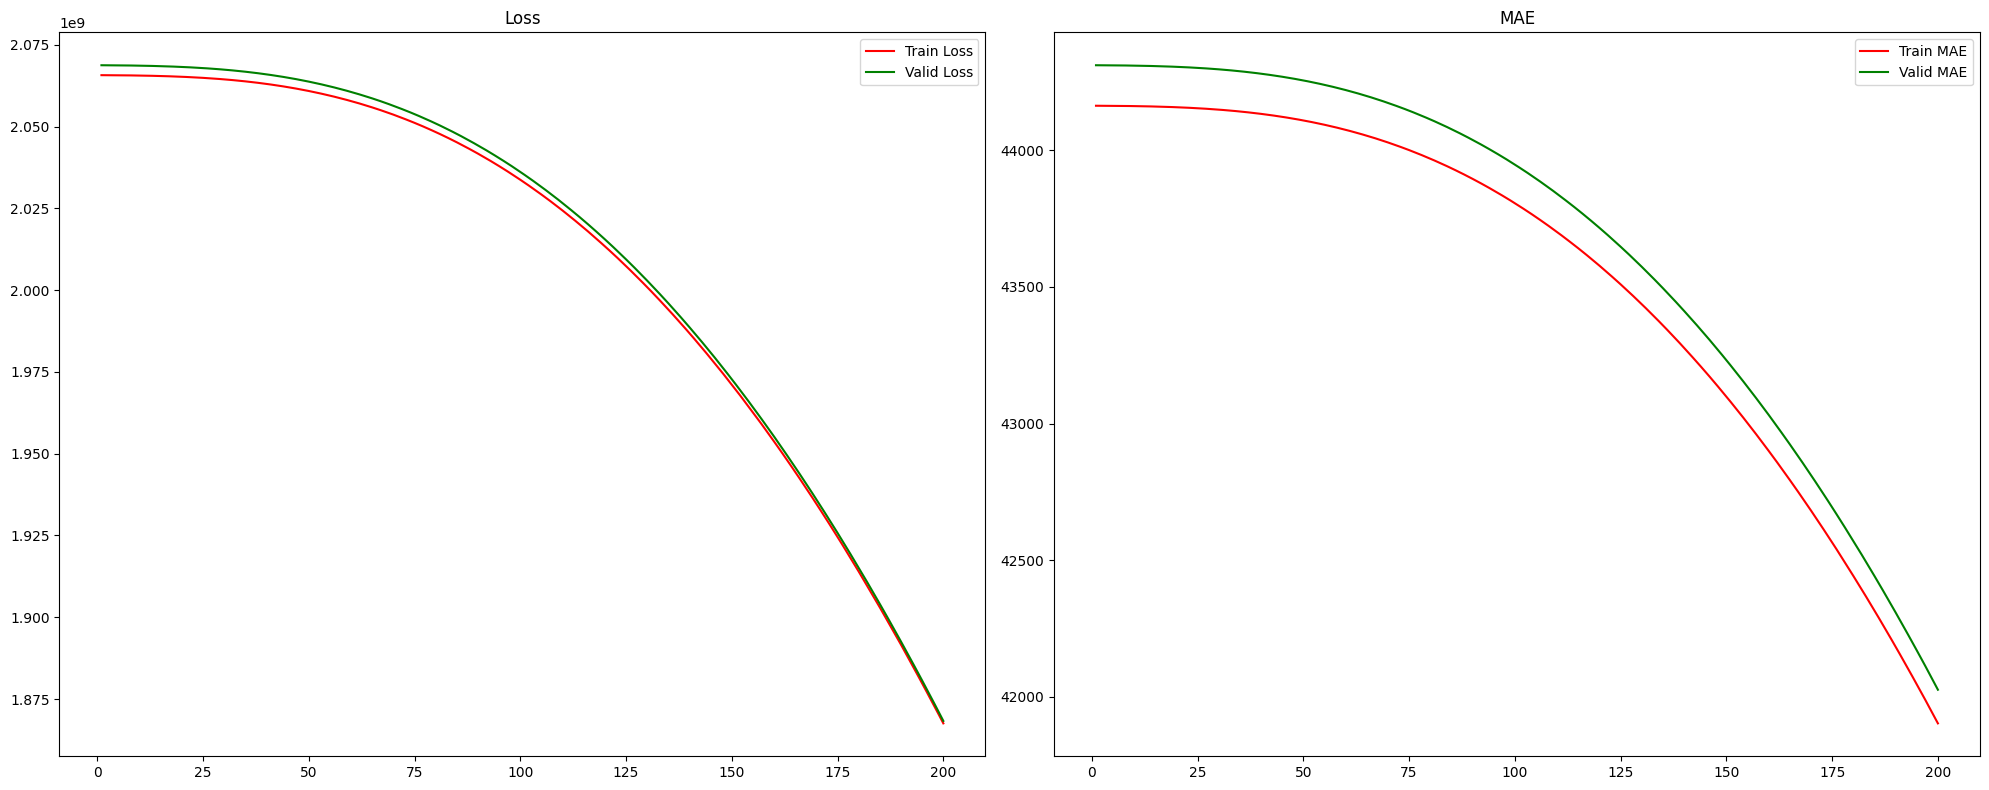

In [24]:
history = model.fit(X_train, y_train, epochs=200, validation_split=0.2)

tr_loss = history.history['loss']
val_loss = history.history['val_loss']

tr_mae = history.history['MAE']
val_mae = history.history['val_MAE']

epochs = [i+1 for i in range(len(tr_loss))]

plt.figure(figsize=(20, 8))

plt.subplot(1, 2, 1)
plt.plot(epochs, tr_loss, 'r', label='Train Loss')
plt.plot(epochs, val_loss, 'g', label='Valid Loss')
plt.title('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, tr_mae, 'r', label='Train MAE')
plt.plot(epochs, val_mae, 'g', label='Valid MAE')
plt.title('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# Precection

In [25]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [26]:
model.save('model.h5')

# using Pytorch

In [27]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [28]:
# Convert to tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

## NN

In [33]:
class CarANN(nn.Module):
    def __init__(self):
        super(CarANN, self).__init__()
        self.l1 = nn.Linear(3, 64)
        self.l2 = nn.Linear(64, 32)
        self.l3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.l3(x)
        return x

model = CarANN()

In [34]:
sum(p.numel() for p in model.parameters())

2369

## Training

In [35]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
for epoch in range(epochs):
    for xb, yb in train_loader:
        xb = xb.float()
        yb = yb.view(-1, 1).float()

        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 10/50, Loss: 2068173952.0000
Epoch 20/50, Loss: 1778263936.0000
Epoch 30/50, Loss: 1495096832.0000
Epoch 40/50, Loss: 1261583872.0000
Epoch 50/50, Loss: 787249856.0000


## Evaluation

In [36]:
len(X_test_tensor)

100

In [38]:
with torch.no_grad():
    y_pred = model(X_test_tensor)

    y_pred = y_pred.view(-1)
    y_true = y_test_tensor.view(-1)

    mse = torch.mean((y_pred - y_true) ** 2).item()
    mae = torch.mean(torch.abs(y_pred - y_true)).item()
    rmse = mse ** 0.5

print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MSE: 665673408.0000
MAE: 23939.4395
RMSE: 25800.6474


In [39]:
ss_res = torch.sum((y_true - y_pred) ** 2)
ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

print(f"R2 Score: {r2.item():.4f}")

R2 Score: -4.2967
